# Open CV Tutorials


We talked about Neural Networks, And then we said that for images for instance for image classification we can use each pixel as one neuron. But we said that we can go for CNN for convolutional filters and neural network that is suitable for images.

But before CNN, we havethis pipeline

```bsh
Image
  ↓
Preprocessing
  ↓
Hand-crafted Feature Extraction
  ↓
Feature Vector
  ↓
Machine Learning
  ↓
Prediction
```

for instance the images of tumors, before giving the full image to svm, we used some approachs liek edge detection, corner detection, HOG, SIFT , ORB , Color histogram and extract features and liek numeric tables and then 




For example

### edge detection

![edge_detection1](https://cdn.learnopencv.com/wp-content/uploads/2021/06/04093732/input_image-1.jpg)


![edge_detection2](https://cdn.learnopencv.com/wp-content/uploads/2021/06/04093729/canny_edge.png)


### Corner detection

![corner_detection1](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEjBwtJ8VJk6BVIX9ZUvJxmWmAIzXtX6kGOIuA8wF5adZbxX1NOc2zJVYC_-9BBLIYQXngyil4HUpoGiGiEQpWHZppX4CEldnfJKMFETR_iIS76RWtYHuksEss0clQjWRM0kARl6mdMcgeQ/s1600/harris.jpg)




```bsh
Image
 ↓
HOG
 ↓
[0.2, 0.8, 0.1, ..., 0.4]
 ↓
SVM
 ↓
Car / Person
```

in classical computer vision, human decide which features are important and we can extract for processing.


But when CNN comes, the story change and why we do featrue extraction we can let network to foudn which features are suitable with kernel weights and then maxpooling, and each cnvolution filters and layers from the top level they can features featurs and each layer reprsent one feature so teh deep learning in without featrue extraction.


![feature_extraction_in_DL](https://www.baeldung.com/wp-content/uploads/sites/4/2023/08/Machine-Learning-vs-Deep-Learning1.png)

so classic approach we have

```bsh
Image
 ↓
OpenCV
 ↓
HOG / SIFT / ORB
 ↓
Feature Vector
 ↓
SVM
 ↓
Prediction
```


and this is Deep Learning
```bsh

Image
 ↓
CNN
 ├── Convolution Layers
 │      ↓
 │   Learned Features
 │
 └── Classifier
        ↓
     Prediction

```

for exampel in the initial layers of CNN we have soemthign like 

```bsh
Edges
 ↓
Textures
 ↓
Shapes
 ↓
Object Parts
 ↓
High-level Features
```

But it doesnt mean , we donot need openCV, open cv can be used for preprocessing and post processing.


we are going to look at these things

first install via

```bsh
pip install opencv-python
```

to verify that : 


In [1]:
import cv2

print(cv2.__version__)

5.0.0


In [2]:
# Show images

import cv2

image = cv2.imread("/Users/apm/Desktop/Deep_Learning_Tutorial/linux.png")


In [5]:
#actually opencv , show pictures as numpuy arrat

print(type(image))
print(image.shape)



<class 'numpy.ndarray'>
(320, 320, 3)


In [ ]:
'''
Height = 720
Width  = 1280
Channels = 3

OpenCV by default use BGR not RGB
'''

#show the image 

cv2.imshow("My Image", image)

cv2.waitKey(0) #it means that , it wait until user press soemthing

cv2.destroyAllWindows()

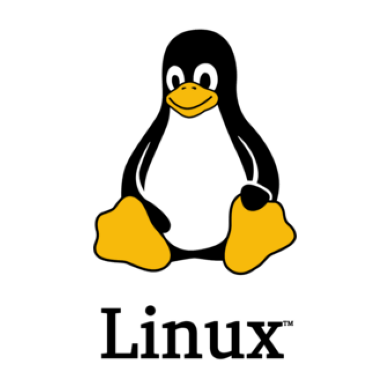

In [3]:
#for jupyter notebool it is betetr to use with amtplotlib

import matplotlib.pyplot as plt

plt.imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()


(224, 120, 3)


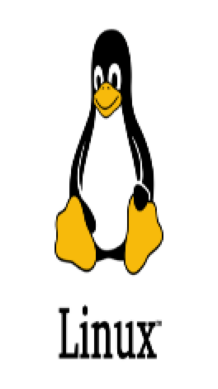

In [13]:
# Resizing the image
#sometime for inputing the neural network is important for us to get specific size

resized = cv2.resize(
    image,
    (120, 224)
)

print(resized.shape)

'''
Original Image
      ↓
cv2.resize()
      ↓
224 × 224
      ↓
CNN

''' 



plt.imshow(
    cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()


(28, 28, 3)


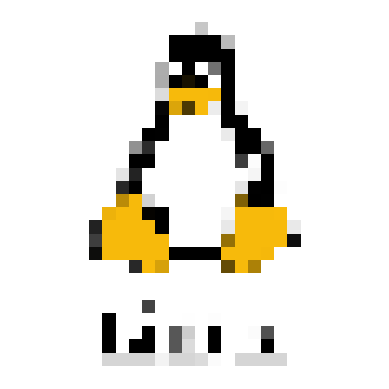

In [12]:
# Resizing the image
#sometime for inputing the neural network is important for us to get specific size

resized = cv2.resize(
    image,
    (28, 28)
)

print(resized.shape)

'''
Original Image
      ↓
cv2.resize()
      ↓
224 × 224
      ↓
CNN

''' 



plt.imshow(
    cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()


(224, 224, 3)


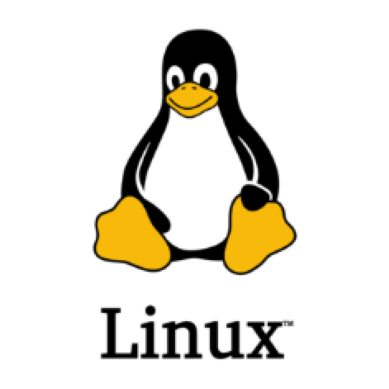

In [14]:
# Resizing the image
#sometime for inputing the neural network is important for us to get specific size

resized = cv2.resize(
    image,
    (224, 224)
)

print(resized.shape)

'''
Original Image
      ↓
cv2.resize()
      ↓
224 × 224
      ↓
CNN

''' 



plt.imshow(
    cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()


In [16]:
def show_image(image):
    plt.imshow(
        cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    )

    plt.axis("off")
    plt.show()
    

(320, 320)


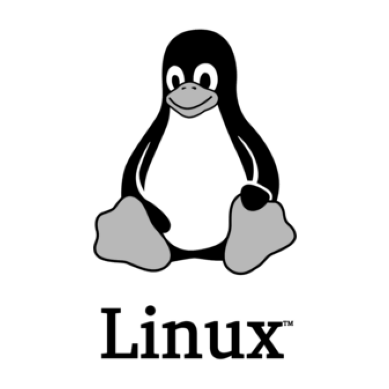

In [17]:
# convert to grayscale 

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

print(gray.shape)

#heree  we donot have the color information


show_image(gray)


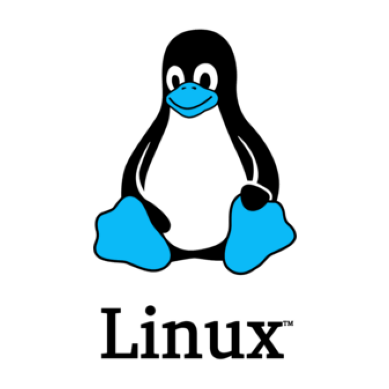

In [18]:
#BGR to RGB

rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

show_image(rgb)

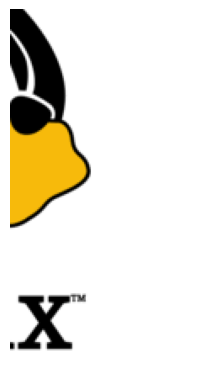

In [ ]:
# for cropping becausse it si numpy we can do easily with

cropped = image[
    100:400,
    200:600
]

show_image(cropped)

#this can be sued for Region of Interest (ROI)

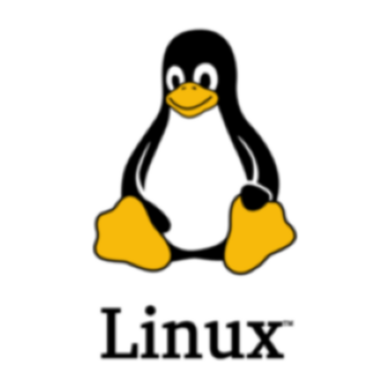

In [20]:
# for decreaisng noise or more smooth we can use blure

blurred = cv2.GaussianBlur(
    image,
    (5, 5),
    0
)

show_image(blurred)
#also consioder the kernel is exactly this

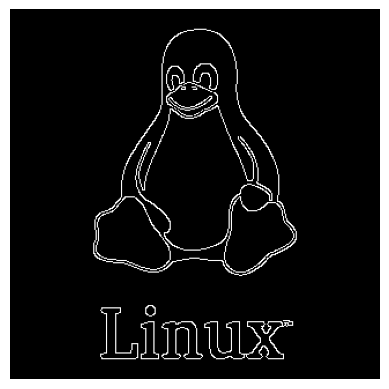

In [21]:
# Canny

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

edges = cv2.Canny(
    gray,
    100,
    200
)


show_image(edges)


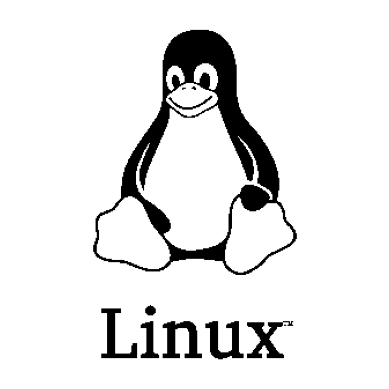

In [22]:
edges = cv2.Canny(
    gray,
    100,
    200
)

_, binary = cv2.threshold(
    gray,
    127,
    255,
    cv2.THRESH_BINARY
)

'''

pixel > 127 --> 255

pixel <=127 -->0

'''

show_image(binary)

# Morphological Operations




In [23]:
#finding counters
# 

contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

#for finding the marze ashya


In [24]:
print(len(contours))

1


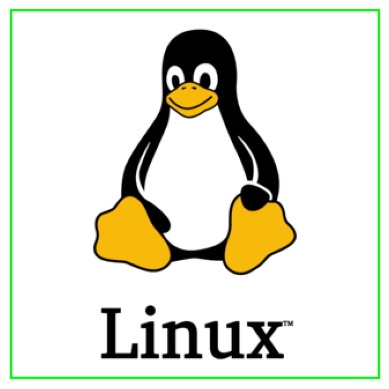

In [25]:
#for drawing the contours

contour_image = cv2.drawContours(
    image.copy(),
    contours,
    -1,
    (0, 255, 0),
    2
)

show_image(contour_image)



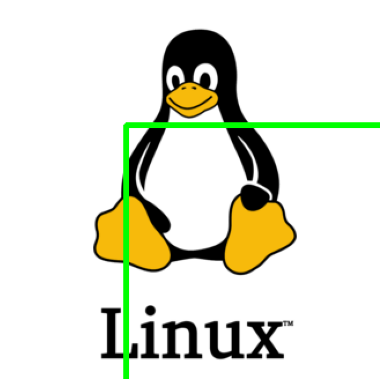

In [26]:
cv2.rectangle(
    image,
    (100, 100),
    (400, 400),
    (0, 255, 0),
    3
)

show_image(image)





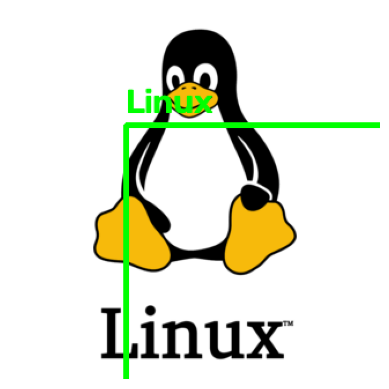

In [28]:
cv2.putText(
    image,
    "Linux",
    (100, 90),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 255, 0),
    2
)

show_image(image)

In [29]:
#saving
cv2.imwrite(
    "result.jpg",
    image
)

True

In [ ]:
cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    cv2.imshow(
        "Webcam",
        frame
    )

    if cv2.waitKey(1) == ord("q"):
        break

cap.release()

cv2.destroyAllWindows()

KeyboardInterrupt: 

: 


--------
---------
# Object detection


First classically when we have image we must do object detection and then we can send them to Deep learning networks.


![obj_det](https://ibb.co/fMYj0MV)


for instance we have somethign like that

```bsh
full car image

Open CV

finding the regions that is 

crop


and then 
```

and we can do like 

```bsh
cv2.cvtColor()
cv2.GaussianBlur()
cv2.Canny()
cv2.threshold()
cv2.findContours()

```

![obj_det2](https://debuggercafe.com/wp-content/uploads/2020/06/slow_video1_60.jpg)

![obj_det3](https://debuggercafe.com/wp-content/uploads/2020/06/people2.jpg)




But modern we have YOLO , for instance we have

```bsh
Full Car Image
       ↓
      YOLO
       ↓
"License Plate"
x1, y1, x2, y2
       ↓
Crop
       ↓
OCR
       ↓
12 ب 345 67
```



YOLO means **You Only Look Once** which is we give image to detctor and model in one inference fidn object and place of that

```bsh
                 YOLO
                  ↓
        ┌─────────┴─────────┐
        ↓                   ↓
    What is it?         Where is it?
       Car             Bounding Box
                         x,y,w,h
```


for instance we have the street  and then

```bsh
Full Image
    ↓
   YOLO
    ↓
Car     0.97    [x1,y1,x2,y2]
Person  0.94    [x1,y1,x2,y2]
Car     0.91    [x1,y1,x2,y2]

```

but we have more than one 

```bsh
Object Detection
│
├── Two-Stage Detectors
│      ├── R-CNN
│      ├── Fast R-CNN
│      └── Faster R-CNN
│
├── One-Stage Detectors
│      ├── YOLO
│      ├── SSD
│      └── RetinaNet
│
└── Transformer-based Detectors
       └── DETR و خانواده آن

```

R-CNN are soemthign that find potential region and we have fast and fasters

Yolo for fast sdetction and image go to detction network and give objects, boxes and scores and suitable for cameras, automobile, robots and ,....

aLSO We have ssd (sINGLE SHOT MULTIBOX DETECTOR)




And also we have DETR which si DEtection Transformer and we give image to transformer


![yolo](https://imerit.ai/wp-content/uploads/2023/04/Feature_Real-Time-Object-Detection-Using-YOLO.jpg)